# Laboratorio 2 - Aprendizaje de Máquina

## Miembros del grupo

| Nombre             | Código    | Correo electrónico           |
|--------------------|-----------|------------------------------|
| Adrian Velasquez   | 202222737 | a.velasquezs@uniandes.edu.co |

In [504]:
# Importar paquetes
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler, OneHotEncoder


# Preparación

La preparación de los datos se hace con base en la limpieza realizada para el laboratorio 1.

In [505]:
# Variables importantes
DATA_DIRNAME = './data/'
CLEAN_DATA = DATA_DIRNAME + 'clean_data.csv'
TEST_DATA = DATA_DIRNAME + 'test.csv'
MODELS_DIRNAME = './models/'
MODEL_FILENAME = MODELS_DIRNAME + 'model.pkl'

In [506]:
# Importar datos limpios del lab pasado
df = pd.read_csv( CLEAN_DATA )
df.head()

,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,2020-03-21,F,52.000000,109.700000,1.780,34.623154,104.400,103/99,197.000000,0.915,...,High,N,178.000,0.586517,103,99,Hypertension Stage 2,113.190076,18.010,HIGH
1,2020-03-03,F,46.769697,104.469000,1.995,26.248328,86.894,164/90,198.971213,82.000,...,Low,Y,199.458,0.435559,164,90,Hypertension Stage 2,147.000000,18.458,HIGH
2,2022-03-08,M,58.000000,85.880566,1.870,24.559057,99.600,113/91,106.000000,6.809,...,Low,N,187.000,0.532620,113,91,Hypertension Stage 2,33.000000,16.530,HIGH
3,2025-09-17,F,52.000000,107.800000,1.780,34.023482,103.500,111/69,179.000000,73.000,...,Low,Y,178.000,0.581461,111,69,Normal,76.000000,15.930,HIGH
4,2023-09-10,M,57.000000,116.772000,1.569,47.434337,90.737,117/116,254.000000,60.000,...,Low,Y,156.854,0.578311,117,116,Hypertension Stage 2,164.000000,17.755,HIGH


In [507]:
# Cambiar a tipo fecha
df['Date of Service'] = pd.to_datetime(df['Date of Service'])
df.head()

,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,2020-03-21,F,52.000000,109.700000,1.780,34.623154,104.400,103/99,197.000000,0.915,...,High,N,178.000,0.586517,103,99,Hypertension Stage 2,113.190076,18.010,HIGH
1,2020-03-03,F,46.769697,104.469000,1.995,26.248328,86.894,164/90,198.971213,82.000,...,Low,Y,199.458,0.435559,164,90,Hypertension Stage 2,147.000000,18.458,HIGH
2,2022-03-08,M,58.000000,85.880566,1.870,24.559057,99.600,113/91,106.000000,6.809,...,Low,N,187.000,0.532620,113,91,Hypertension Stage 2,33.000000,16.530,HIGH
3,2025-09-17,F,52.000000,107.800000,1.780,34.023482,103.500,111/69,179.000000,73.000,...,Low,Y,178.000,0.581461,111,69,Normal,76.000000,15.930,HIGH
4,2023-09-10,M,57.000000,116.772000,1.569,47.434337,90.737,117/116,254.000000,60.000,...,Low,Y,156.854,0.578311,117,116,Hypertension Stage 2,164.000000,17.755,HIGH


In [508]:
# Separar variables independientes y dependientes
TARGET = 'CVD Risk Score'
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [509]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [510]:
# Verificar dimensiones de los conjuntos de entrenamiento
print(f"Valores de entrenamiento X: {X_train.shape}")
print(f"Valores de entrenamiento y: {y_train.shape[0]}")

Valores de entrenamiento X: (1054, 22)
Valores de entrenamiento y: 1054


In [511]:
# Verificar dimensiones de los conjuntos de prueba
print(f"Valores de test X: {X_test.shape}")
print(f"Valores de test y: {y_test.shape[0]}")

Valores de test X: (264, 22)
Valores de test y: 264


In [512]:
# Identificar columnas categóricas y numéricas
cat_cols = X_train.select_dtypes(include=['str']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'datetime']).columns
print(f"Columnas categóricas: {cat_cols}")
print(f"Columnas numéricas: {num_cols}")

Columnas categóricas: Index(['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category', 'CVD Risk Level'],
      dtype='str')
Columnas numéricas: Index(['Date of Service', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
       'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Estimated LDL (mg/dL)'],
      dtype='str')


# Modelo polinomial

Para el modelo polinomial se tendrá en cuenta el `PolynomialFeatures` de `sklearn.preprocessing` para generar características polinomiales a partir de las variables numéricas. Esto permitirá capturar relaciones no lineales entre las variables independientes y la variable dependiente. Se evaluará el rendimiento del modelo polinomial utilizando métricas como el error cuadrático medio (MSE) y el coeficiente de determinación ($R^2$) para comparar con otros modelos lineales y polinomiales regularizados.

## Definir pipeline para modelo polinomial

In [513]:
# Escoger columnas a eliminar de acuerdo al negocio
cols_to_drop = [
    'CVD Risk Level', # Representa una categorización del riesgo, pero el modelo se enfocará en predecir el puntaje de riesgo continuo
    'Date of Service', # No es relevante para el modelo
    'Blood Pressure (mmHg)', # Se puede descomponer en sistólica y diastólica
    'Systolic BP', # Está incluido en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Diastolic BP', # Está incluido en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Weight (kg)', # Se puede descomponer en BMI, por lo que se puede eliminar para evitar multicolinealidad
    'Height (cm)', # Se puede descomponer en BMI, por lo que se puede eliminar para evitar multicolinealidad
    'Height (m)', # Se elimina para evitar multicolinealidad con Height (cm) y Weight (kg)
    'Estimated LDL (mg/dL)', # Se puede descomponer en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'HDL (mg/dL)', # Se puede descomponer en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Blood Pressure Category', # Representa una categorización de la presión arterial, pero el modelo se enfocará en predecir el puntaje de riesgo continuo
]

In [514]:
# Definir función para eliminar columnas
def drop_columns( xt ):
    return xt.drop(columns=cols_to_drop)

dropper = FunctionTransformer(drop_columns)

In [515]:
# Pipeline para transformar variables numéricas con polinomios
poli_num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ('poly', PolynomialFeatures(degree=2))
    ]
)

In [516]:
# Pipeline para transformar variables categóricas con one-hot encoding y polinomios
poli_cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [517]:
# Adquirir nuevamente las columnas cat y num
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
num_cols = [c for c in num_cols if c not in cols_to_drop]

In [518]:
# Combinar transformadores numéricos y categóricos en un preprocesador
poli_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poli_num_transformer, num_cols), # Aplicar el transformador polinomial a las columnas numéricas
        ("cat", poli_cat_transformer, cat_cols) # Aplicar el transformador de one-hot encoding a las columnas categóricas
    ]
)

In [519]:
# Combinar transformadores en un preprocesador
poli_pipe = Pipeline(
    steps=[
        ("dropper", dropper), # Aplicar el transformador de eliminación a todas las columnas
        ("preprocessor", poli_preprocessor), # Aplicar el preprocesador polinomial a las columnas restantes
        ("model", LinearRegression()) # Modelo de regresión
    ]
)

In [520]:
# Visualizar pipeline
set_config(display="diagram")
poli_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dropper', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x1156f47d0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

## Modelo polinomial de grado 2

In [521]:
# Hacer fit del modelo
poli_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dropper', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x1156f47d0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

In [522]:
# Ver los coeficientes del modelo
poli_model = poli_pipe.named_steps["model"]
num_coeficientes = len(poli_model.coef_)
print("Número de coeficientes:", num_coeficientes)

Número de coeficientes: 39


### Validación del modelo polinomial

In [523]:
# Rendimiento inicial
y_train_pred_poli = poli_pipe.predict(X_train)

In [524]:
# Métricas
print(f'------ Modelo de regresión polinomial grado 2 ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_poli)):.2f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_poli):.2f}")
print(f'R²: {r2_score(y_train, y_train_pred_poli):.2f}')

------ Modelo de regresión polinomial grado 2 ----
RMSE: 5.40
MAE: 1.86
R²: 0.10


### Estimación de generalización del modelo polinomial con validación cruzada

In [525]:
# Predecir
y_test_pred_poli = poli_pipe.predict(X_test)

In [526]:
# Métricas
print(f'------ Modelo de regresión polinomial grado 2 - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poli)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poli):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred_poli):.2f}')

------ Modelo de regresión polinomial grado 2 - Resultados en test ----
RMSE: 10.78
MAE: 2.79
R²: 0.04


## Búsqueda de hiperparámetros para modelo polinomial

In [527]:
# Definir el grid para GridSearchCV
param_grid = {
    'preprocessor__num__poly__degree': [2, 3, 4, 5, 6], # Grados del polinomio a evaluar
}

In [528]:
# Definir el GridSearchCV
grid = GridSearchCV(
    estimator=poli_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [529]:
# Fit del GridSearchCV
grid.fit(X_train, y_train)

/Users/adrianv/Documents/Universidad/2026_10/Ciberseguridad/Laboratorios/L2/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [530]:
# Mejor config
print("Mejor configuración:", grid.best_params_)

Mejor configuración: {'preprocessor__num__poly__degree': 2}


In [531]:
mejor_modelo = grid.best_estimator_

In [532]:
y_test_pred = mejor_modelo.predict(X_test)
print(f'------ Mejor modelo - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

------ Mejor modelo - Resultados en test ----
RMSE: 10.78
MAE: 2.79
R²: 0.04


In [533]:
scores = cross_val_score(mejor_modelo, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
mse_scores = -scores

print(f"MSE promedio: {mse_scores.mean():.4f}")
print(f"Desviación Estándar del MSE: {mse_scores.std():.4f}")
print(f"Intervalo de confianza (aprox): [{mse_scores.mean() - 2*mse_scores.std():.4f}, {mse_scores.mean() + 2*mse_scores.std():.4f}]")

MSE promedio: 31.1861
Desviación Estándar del MSE: 29.6558
Intervalo de confianza (aprox): [-28.1256, 90.4978]


## Curvas de validación para modelo polinomial

In [534]:
# Definir rango de grados polinomiales a evaluar
degrees = range(1, 8)

# Arrays para almacenar resultados
train_scores = []
train_scores_std = []
val_scores = []
val_scores_std = []

# Validación cruzada con KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("Evaluando diferentes grados polinomiales...")
for degree in degrees:
    print(f"Grado {degree}...")

    # Crear pipeline con el grado actual
    current_pipe = Pipeline(
        steps=[
            ("dropper", dropper),
            ("preprocessor", ColumnTransformer(
                transformers=[
                    ("num", Pipeline([
                        ("imputer", SimpleImputer(strategy="mean")),
                        ("scaler", StandardScaler()),
                        ('poly', PolynomialFeatures(degree=degree))
                    ]), num_cols),
                    ("cat", poli_cat_transformer, cat_cols)
                ]
            )),
            ("model", LinearRegression())
        ]
    )

    # Validación cruzada para conjunto de entrenamiento
    train_scores_cv = []
    val_scores_cv = []

    for train_idx, val_idx in kfold.split(X_train):
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        # Entrenar modelo
        current_pipe.fit(X_train_fold, y_train_fold)

        # Predecir en entrenamiento
        y_train_pred = current_pipe.predict(X_train_fold)
        train_rmse = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
        train_scores_cv.append(train_rmse)

        # Predecir en validación
        y_val_pred = current_pipe.predict(X_val_fold)
        val_rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
        val_scores_cv.append(val_rmse)

    # Calcular promedio y desviación estándar
    train_scores.append(np.mean(train_scores_cv))
    train_scores_std.append(np.std(train_scores_cv))
    val_scores.append(np.mean(val_scores_cv))
    val_scores_std.append(np.std(val_scores_cv))

print("Evaluación completada!")

Evaluando diferentes grados polinomiales...
Grado 1...
Grado 2...
Grado 3...
Grado 4...
Grado 5...
Grado 6...
Grado 7...
Evaluación completada!


In [535]:
# Convertir a arrays de numpy para facilitar cálculos
train_scores = np.array(train_scores)
train_scores_std = np.array(train_scores_std)
val_scores = np.array(val_scores)
val_scores_std = np.array(val_scores_std)

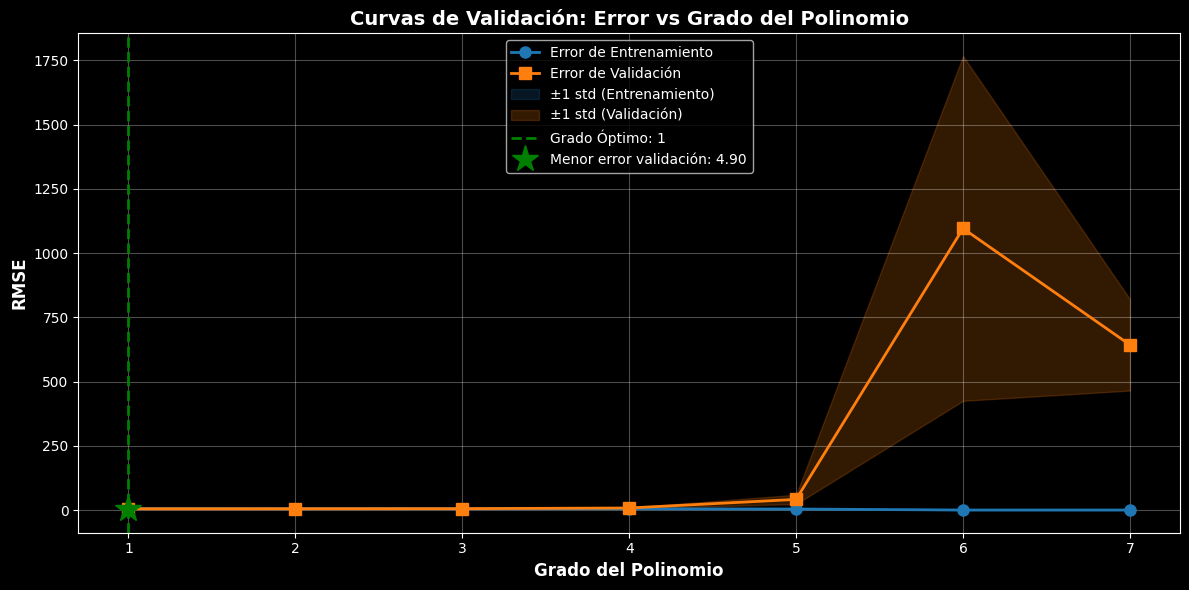

In [536]:
# Crear la figura con curvas de validación
plt.figure(figsize=(12, 6))

# Graficar errores promedio
plt.plot(degrees, train_scores, 'o-', color='#1f77b4', label='Error de Entrenamiento', linewidth=2, markersize=8)
plt.plot(degrees, val_scores, 's-', color='#ff7f0e', label='Error de Validación', linewidth=2, markersize=8)

# Agregar bandas de variabilidad (±1 desviación estándar)
plt.fill_between(degrees,
                 train_scores - train_scores_std,
                 train_scores + train_scores_std,
                 alpha=0.2, color='#1f77b4', label='±1 std (Entrenamiento)')

plt.fill_between(degrees,
                 val_scores - val_scores_std,
                 val_scores + val_scores_std,
                 alpha=0.2, color='#ff7f0e', label='±1 std (Validación)')

# Identificar el mejor grado (menor error de validación)
best_degree = degrees[np.argmin(val_scores)]
best_val_score = np.min(val_scores)

# Marcar el punto óptimo
plt.axvline(x=best_degree, color='green', linestyle='--', linewidth=2,
            label=f'Grado Óptimo: {best_degree}')
plt.plot(best_degree, best_val_score, 'g*', markersize=20,
         label=f'Menor error validación: {best_val_score:.2f}')

# Configurar gráfico
plt.xlabel('Grado del Polinomio', fontsize=12, fontweight='bold')
plt.ylabel('RMSE', fontsize=12, fontweight='bold')
plt.title('Curvas de Validación: Error vs Grado del Polinomio', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.tight_layout()
plt.show()

In [537]:
# Mostrar tabla con resultados detallados
resultados_df = pd.DataFrame({
    'Grado': list(degrees),
    'RMSE Train (μ)': [f'{score:.4f}' for score in train_scores],
    'RMSE Train (σ)': [f'{std:.4f}' for std in train_scores_std],
    'RMSE Val (μ)': [f'{score:.4f}' for score in val_scores],
    'RMSE Val (σ)': [f'{std:.4f}' for std in val_scores_std],
    'Gap (Val - Train)': [f'{val - train:.4f}' for val, train in zip(val_scores, train_scores)]
})

print("\n" + "="*80)
print("RESULTADOS DE VALIDACIÓN CRUZADA POR GRADO POLINOMIAL")
print("="*80)
print(resultados_df.to_string(index=False))
print("="*80)


RESULTADOS DE VALIDACIÓN CRUZADA POR GRADO POLINOMIAL
 Grado RMSE Train (μ) RMSE Train (σ) RMSE Val (μ) RMSE Val (σ) Gap (Val - Train)
     1         5.4123         0.5178       4.8968       2.5270           -0.5155
     2         5.3578         0.5138       4.9827       2.4723           -0.3751
     3         5.1568         0.4970       5.3090       2.2803            0.1522
     4         4.7839         0.4561       7.9321       1.6034            3.1482
     5         3.8601         0.4223      41.3276      18.2805           37.4675
     6         0.0000         0.0000    1096.2484     671.1255         1096.2484
     7         0.0000         0.0000     643.0834     178.0588          643.0834


### Análisis del Trade-off Sesgo-Varianza

**Interpretación de las curvas de validación:**

1. **Región de Alto Sesgo (Underfitting)**:
   - Ocurre con grados polinomiales bajos (1-2).
   - Tanto el error de entrenamiento como el de validación son altos.
   - El modelo es demasiado simple para capturar la complejidad de los datos.
   - **Síntoma**: Ambas curvas están cerca y ambas muestran errores altos.

2. **Punto Óptimo**:
   - Se encuentra en el grado polinomial donde el error de validación alcanza su mínimo.
   - Representa el mejor balance entre sesgo y varianza.
   - El grado óptimo se identifica en el código anterior (ver línea verde en el gráfico).
   - En este punto, el modelo generaliza mejor a datos no vistos.

3. **Región de Alta Varianza (Overfitting)**:
   - Ocurre con grados polinomiales altos (>4).
   - El error de entrenamiento disminuye, pero el error de validación aumenta.
   - El modelo captura ruido en los datos de entrenamiento.
   - **Síntoma**: Brecha creciente entre las curvas (gap).
   - El modelo pierde capacidad de generalización.

4. **Variabilidad (Bandas de confianza)**:
   - Las bandas sombreadas muestran ±1 desviación estándar.
   - Mayor variabilidad indica mayor sensibilidad a los datos de entrenamiento.
   - Modelos complejos tienden a mostrar mayor variabilidad en validación.

5. **Control de Complejidad**:
   - El grado del polinomio controla la complejidad del modelo.
   - Aumentar el grado incrementa la capacidad del modelo pero también el riesgo de sobreajuste.
   - La validación cruzada permite seleccionar el grado que mejor generaliza.

In [538]:
# Análisis adicional: Identificar inicio de sobreajuste
gaps = val_scores - train_scores
print("\n" + "="*80)
print("ANÁLISIS DE SOBREAJUSTE")
print("="*80)
print(f"Grado óptimo (menor error de validación): {best_degree}")
print(f"Error de validación mínimo: {best_val_score:.4f}")
print(f"\nBrecha (Gap) entre validación y entrenamiento:")
for i, degree in enumerate(degrees):
    indicator = " ← ÓPTIMO" if degree == best_degree else ""
    overfitting_indicator = " [SOBREAJUSTE]" if gaps[i] > 2 * gaps[np.argmin(val_scores)] else ""
    print(f"  Grado {degree}: {gaps[i]:.4f}{indicator}{overfitting_indicator}")
print("="*80)
print("\nNota: El sobreajuste comienza a evidenciarse cuando la brecha entre")
print("      el error de validación y entrenamiento crece significativamente.")
print("="*80)


ANÁLISIS DE SOBREAJUSTE
Grado óptimo (menor error de validación): 1
Error de validación mínimo: 4.8968

Brecha (Gap) entre validación y entrenamiento:
  Grado 1: -0.5155 ← ÓPTIMO [SOBREAJUSTE]
  Grado 2: -0.3751 [SOBREAJUSTE]
  Grado 3: 0.1522 [SOBREAJUSTE]
  Grado 4: 3.1482 [SOBREAJUSTE]
  Grado 5: 37.4675 [SOBREAJUSTE]
  Grado 6: 1096.2484 [SOBREAJUSTE]
  Grado 7: 643.0834 [SOBREAJUSTE]

Nota: El sobreajuste comienza a evidenciarse cuando la brecha entre
      el error de validación y entrenamiento crece significativamente.


# Modelos de regresión lineal regularizados

# Modelo polinomial regularizado

# Selección del mejor modelo

# Intervalos de confianza